In [116]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorly as tl
import matplotlib.pyplot as plt
from tensorly.decomposition import matrix_product_state
import torch
from datetime import datetime

In [117]:
ratings=pd.read_csv("F://ml-1m//ratings.csv")
user=pd.read_csv("F://ml-1m//users.csv")

ratings_df=pd.DataFrame(ratings)
user_df=pd.DataFrame(user)

In [118]:
user_df.head()

,0,Unnamed: 1,Unnamed: 2
0,1,F,1
1,2,M,56
2,3,M,25
3,4,M,45
4,5,M,25


In [119]:
ratings_df.columns=['userId', 'movieId', 'rating', 'timestamp']

In [120]:
ratings_df['timestamp']=ratings_df['timestamp'].astype('datetime64[s]')
ratings_df=ratings_df.assign(session=pd.cut(ratings_df.timestamp.dt.hour,[0,6,12,18,24],labels=[1,2,3,4]))
ratings_df=ratings_df.dropna(axis=0)

In [121]:
ratings_df['movieId'].nunique()

3702

In [122]:
ratings_df['rating'].head()

0    5
1    3
2    3
3    4
4    5
Name: rating, dtype: int64

In [123]:
ratings_df["rating"] = ratings_df["rating"] / ratings_df["rating"].max()

In [124]:
ratings_df

,userId,movieId,rating,timestamp,session
0,1,1193,1.0,2000-12-31 22:12:40,4
1,1,661,0.6,2000-12-31 22:35:09,4
2,1,914,0.6,2000-12-31 22:32:48,4
3,1,3408,0.8,2000-12-31 22:04:35,4
4,1,2355,1.0,2001-01-06 23:38:11,4
...,...,...,...,...,...
1000204,6040,1091,0.2,2000-04-26 02:35:41,1
1000205,6040,1094,1.0,2000-04-25 23:21:27,4
1000206,6040,562,1.0,2000-04-25 23:19:06,4
1000207,6040,1096,0.8,2000-04-26 02:20:48,1


In [125]:
ratings1=np.zeros((6040,3952, 4))
# ratings_df dataframe to ratings1 ndarray
for row in ratings_df.itertuples(index = True):
    ratings1[  row.userId-1,row.movieId-1, row.session-1]  = row.rating

# compute the non-zero elements in the ratings1 tensor
matrix_size = np.prod(ratings1.shape)
interaction = np.flatnonzero(ratings1).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', ratings1.shape)
print('sparsity: {:.4f}%'.format(sparsity))
interaction

dimension:  (6040, 3952, 4)
sparsity: 0.9895%


944812

In [126]:
ratings_train1, ratings_train2, ratings_train3 = ratings_df.query('userId <= 2000' ).copy(), ratings_df.query('userId > 2000 and userId <=4000').copy(), ratings_df.query('userId >4000').copy()

In [127]:
ratings_train11 = ratings_train1.query('movieId <= 2000' ).copy()
ratings_train22= ratings_train2.query('movieId > 2000 and movieId <= 3000').copy()
ratings_train33= ratings_train3.query('movieId>3000').copy()

In [128]:
user_df=user_df.copy()
user_df.columns=['userId',  'gender', 'age']

user_df['gender'][user_df['gender']=='M']=1
user_df['gender'][user_df['gender']=='F']=2
user_df['age'][(user_df['age']>=0) & (user_df['age']<=18)] =1
user_df['age'][(user_df['age']>18) & (user_df['age']<=25)] =2
user_df['age'][(user_df['age']>25) & (user_df['age']<=35)] =3
user_df['age'][(user_df['age']>35) & (user_df['age']<=50)] =4
user_df['age'][(user_df['age']>50)]=5

C:\Users\user\Anaconda4\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\user\Anaconda4\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
C:\Users\user\Anaconda4\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\user\Anaconda4\lib\site-packages\ipykernel_launc

In [129]:
#initializing emoty nd arrays
ratings1=np.zeros((2000,2000, 4))
user1=np.zeros((2000,5,2))

In [130]:
user_df1, user_df2, user_df3 = user_df.query('userId <=2000').copy(), user_df.query('userId > 2000 and userId <=4000').copy(), user_df.query('userId >4000').copy()

In [131]:
n_users1 = user_df1['userId'].unique().shape[0]
n_movies1 = ratings_train11['movieId'].unique().shape[0]
n_session1 = ratings_train11['session'].unique().shape[0]

n_age = user_df['age'].unique().shape[0]
n_gender = user_df['gender'].unique().shape[0]

n_users1,n_movies1, n_session1, n_age, n_gender

(2000, 1759, 4, 5, 2)

In [132]:
# ratings_df dataframe to ratings1 ndarray
for row in ratings_train11.itertuples(index = True):
    ratings1[row.userId-1, row.movieId-1, row.session-1]  = row.rating

# compute the non-zero elements in the ratings1 tensor
matrix_size = np.prod(ratings1.shape)
interaction = np.flatnonzero(ratings1).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', ratings1.shape)
print('sparsity: {:.4f}%'.format(sparsity))
interaction

dimension:  (2000, 2000, 4)
sparsity: 1.0845%


173522

In [133]:
# user_df dataframe to user1 ndarray
for row in user_df1.itertuples(index = True):
    user1[row.userId-1, row.age-1, row.gender-1] = 1

# compute the non-zero elements in the user1 tensor
matrix_size = np.prod(user1.shape)
interaction = np.flatnonzero(user1).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', user1.shape)
print('sparsity: {:.4f}%'.format(sparsity))

dimension:  (2000, 5, 2)
sparsity: 10.0000%


In [134]:
# ndarray to tensorflow tensor
t1=tf.convert_to_tensor(ratings1)
t2=tf.convert_to_tensor(user1)

In [135]:
updated2=pd.merge(ratings_train22, user_df2, on='userId', how='inner')

In [136]:
#initializing emoty nd arrays
ratings2=np.zeros((6040, 3952, 4))
user2=np.zeros((6040, 5, 2))

In [137]:
# ratings_df dataframe to ratings1 ndarray
for row in updated2.itertuples(index = True):
    ratings2[row.userId-1, row.movieId-1, row.session-1]  = row.rating

# compute the non-zero elements in the ratings1 tensor
matrix_size = np.prod(ratings2.shape)
interaction = np.flatnonzero(ratings2).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', ratings2.shape)
print('sparsity: {:.4f}%'.format(sparsity))
interaction

dimension:  (6040, 3952, 4)
sparsity: 0.0862%


82258

In [138]:
ratings22=ratings2[~(ratings2==0).all((2,1))]
ratings22 = np.asarray(ratings22)
ratings23=ratings22[~(ratings22==0).all((2,1))]
ratings23[ratings23.sum(2) != 0].shape
xs,ys,zs = np.where(ratings23!=0) 
# for 4D object
# xs,ys,zs,as = np.where(d!=0) 

# extract cube with extreme limits of where are the values != 0
result2 = ratings23[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1] 
# for 4D object
# result = d[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1,min(as):max(as)+1]
result2.shape

(1949, 1000, 4)

In [139]:
# user_df dataframe to user1 ndarray
for row in updated2.itertuples(index = True):
    user2[row.userId-1, row.age-1, row.gender-1] = 1

# compute the non-zero elements in the user1 tensor
matrix_size = np.prod(user2.shape)
interaction = np.flatnonzero(user2).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', user2.shape)
print('sparsity: {:.4f}%'.format(sparsity))

dimension:  (6040, 5, 2)
sparsity: 3.2268%


In [140]:
user22=user2[~(user2==0).all((2,1))]
user22 = np.asarray(user22)
user23=user22[~(user22==0).all((2,1))]
user23[user23.sum(2) != 0].shape
xs,ys,zs = np.where(user23!=0) 
# for 4D object
# xs,ys,zs,as = np.where(d!=0) 

# extract cube with extreme limits of where are the values != 0
result2u = user23[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1] 
# for 4D object
# result = d[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1,min(as):max(as)+1]
result2u.shape

(1949, 5, 2)

In [141]:
updated3=pd.merge(ratings_train33, user_df3, on='userId', how='inner')

In [142]:
#initializing emoty nd arrays
ratings3=np.zeros((6040, 3952, 4))
user3=np.zeros((6040, 5, 2))

In [143]:
# ratings_df dataframe to ratings1 ndarray
for row in updated3.itertuples(index = True):
    ratings3[row.userId-1, row.movieId-1, row.session-1]  = row.rating

# compute the non-zero elements in the ratings1 tensor
matrix_size = np.prod(ratings3.shape)
interaction = np.flatnonzero(ratings3).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', ratings3.shape)
print('sparsity: {:.4f}%'.format(sparsity))
interaction

dimension:  (6040, 3952, 4)
sparsity: 0.0602%


57449

In [144]:
ratings33=ratings3[~(ratings3==0).all((2,1))]
ratings33 = np.asarray(ratings33)
ratings233=ratings33[~(ratings33==0).all((2,1))]
ratings233[ratings233.sum(2) != 0].shape
xs,ys,zs = np.where(ratings233!=0) 
# for 4D object
# xs,ys,zs,as = np.where(d!=0) 

# extract cube with extreme limits of where are the values != 0
result3 = ratings233[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1] 
# for 4D object
# result = d[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1,min(as):max(as)+1]
result3.shape

(1974, 952, 4)

In [145]:
# user_df dataframe to user1 ndarray
for row in updated3.itertuples(index = True):
    user3[row.userId-1, row.age-1, row.gender-1] = 1

# compute the non-zero elements in the user1 tensor
matrix_size = np.prod(user3.shape)
interaction = np.flatnonzero(user3).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', user3.shape)
print('sparsity: {:.4f}%'.format(sparsity))

dimension:  (6040, 5, 2)
sparsity: 3.2682%


In [146]:
user22=user3[~(user3==0).all((2,1))]
user22 = np.asarray(user22)
user23=user22[~(user22==0).all((2,1))]
user23[user23.sum(2) != 0].shape
xs,ys,zs = np.where(user23!=0) 
# for 4D object
# xs,ys,zs,as = np.where(d!=0) 

# extract cube with extreme limits of where are the values != 0
result3u = user23[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1] 
# for 4D object
# result = d[min(xs):max(xs)+1,min(ys):max(ys)+1,min(zs):max(zs)+1,min(as):max(as)+1]
result3u.shape

(1974, 5, 2)

In [147]:
# ndarray to tensorflow tensor
t11=tf.convert_to_tensor(result2)
t22=tf.convert_to_tensor(result2u)


In [148]:
t11u=tf.convert_to_tensor(result3)
t22u=tf.convert_to_tensor(result3u)

## <h1> Tensor Train Decompositon <h1>

In [149]:
y1=tl.unfold(t1,0)
y2=tl.unfold(t1,1)
y3=tl.unfold(t1,2)
y1c=tl.unfold(t2,0)
y2c=tl.unfold(t2,1)
y3c=tl.unfold(t2,2)

In [150]:
# Unfolding the incremental tensor
z1=tl.unfold(t11,0)
z2=tl.unfold(t11,1)
z3=tl.unfold(t11,2)
z1c=tl.unfold(t22,0)
z2c=tl.unfold(t22,1)
z3c=tl.unfold(t22,2)

In [151]:
w1=tl.unfold(t11u,0)
w2=tl.unfold(t11u,1)
w3=tl.unfold(t11u,2)
w1c=tl.unfold(t22u,0)
w2c=tl.unfold(t22u,1)
w3c=tl.unfold(t22u,2)

In [169]:
# coupled tensor-train decomposition using ALS
def cttals(t1,user1,y1,y2,y3, y1c,y2c,y3c, max_iter, verbose=False):
    reg=0.0
    latent2=[25]
    test_mae_ctt=[]
    train_mae_ctt=[]
    user_mae=[]
    for latent1 in latent2:
        g1=np.random.randn(1, 2000, latent1).astype('float64')
        g2=np.random.randn(latent1, 2000, 4).astype('float64')
        g3=np.random.randn(4, 4, 1).astype('float64')
        g11=np.random.randn(1, 2000,latent1).astype('float64')
        g22=np.random.randn(latent1,5,2).astype('float64')
        g33=np.random.randn(2 ,2,1).astype('float64')
        for epoch in range(max_iter):

            #optimize g1
            g23=tl.unfold(np.squeeze(tf.tensordot(g2, g3, axes=1)),0)
            g231= np.matmul(g23, tf.transpose(g23))
            #g231=g231+reg*np.eye(g231.shape[0])
            y11= np.matmul(y1, tf.transpose(g23))
            g23c=tl.unfold(np.squeeze(tf.tensordot(g22, g33, axes=1)),0)
            g231c= np.matmul(g23c, tf.transpose(g23c))
            #g231c=g231c+reg*np.eye(g231c.shape[0])
            y11c= np.matmul(y1c, tf.transpose(g23c))
            g1=np.matmul(0.8*(y11)+0.2*(y11c), np.linalg.inv(0.8*(g231)+0.2*(g231c))).astype('float64')


            #optimize g2
            g13= np.kron(tl.unfold(g1, 1), tl.unfold(g3,0))
            g131= np.matmul(g13, tf.transpose(g13))
            #g131=g131+reg*np.eye(g131.shape[0])
            g13i= np.linalg.inv(g131)
            y22= np.matmul(y2, tf.transpose(g13))
            g2=np.matmul(y22, g13i)
            g2=tl.fold(g2,1 , [latent1, 2000, 4]).astype('float64')

            #optimize g3
            g12=tl.unfold(np.squeeze(tf.tensordot(g1, g2, axes=1)),2)
            g121= np.matmul(g12, tf.transpose(g12))
           #g121=g121+reg*np.eye(g121.shape[0])
            g12i = np.linalg.inv(g121)
            y33= np.matmul(y3, tf.transpose(g12))
            g3= np.matmul(y33, g12i)
            g3= tl.fold(g3, 1, [4, 4, 1]).astype('float64')

            #optimize g22
            g113= np.kron(tl.unfold(g1, 1), tl.unfold(g33,0))
            g1331= np.matmul(g113, tf.transpose(g113))
            #g1331=g1331+reg*np.eye(g1331.shape[0])
            g133i= np.linalg.inv(g1331)
            y222= np.matmul(y2c, tf.transpose(g113))
            g22=np.matmul(y222, g133i)
            g22=tl.fold(g22,1 , [latent1, 5,2]).astype('float64')

            #optimize g33
            g112=tl.unfold((tf.tensordot(g1, g22, axes=1)),2)
            g1221= np.matmul(g112, tf.transpose(g112))
            #g1221=g1221+reg*np.eye(g1221.shape[0])
            g122i = np.linalg.inv(g1221)
            y333= np.matmul(y3c, tf.transpose(g112))
            g33= np.matmul(y333, g122i)
            g33= tl.fold(g33, 1, [2, 2, 1]).astype('float64')
           

        
   
      
    return g1, g2, g3, g22, g33

In [170]:
def cttals1(t11,user2,z1,z2,z3, z1c,z2c,z3c, max_iter, verbose=False):
    reg=0
    latent2=[25]
    test_mae_ctt=[]
    train_mae_ctt=[]
    user_mae=[]
    a11=[0.8]
    for latent1 in latent2:
        for a1 in a11:
            g1=np.random.randn(1, 1949, latent1).astype('float64')
            g2=np.random.randn(latent1, 1000, 4).astype('float64')
            g3=np.random.randn(4, 4, 1).astype('float64')
            g11=np.random.randn(1, 1949,latent1).astype('float64')
            g22=np.random.randn(latent1,5,2).astype('float64')
            g33=np.random.randn(2 ,2,1).astype('float64')
            for epoch in range(max_iter):
                

                #optimize g1
                g23= tf.tensordot(g2, g3, axes=1)
                g23=tl.unfold(np.squeeze(g23),0)
                g231= np.matmul(g23, tf.transpose(g23))
                g231=g231+reg*np.eye(g231.shape[0])
              
                y11= np.matmul(z1, tf.transpose(g23))
                g23c= tf.tensordot(g22, g33, axes=1)
                g23c=tl.unfold(np.squeeze(g23c),0)
                g231c= np.matmul(g23c, tf.transpose(g23c))
                g231c=g231c+(reg*np.eye(g231c.shape[0]))
                y11c= np.matmul(z1c, tf.transpose(g23c))
                g1=np.matmul(a1*(y11)+(1-a1)*(y11c), np.linalg.inv(a1*(g231)+(1-a1)*(g231c))).astype('float64')
                #g1=0.7*np.matmul(y11, np.linalg.inv(g231))+0.3*np.matmul(y11c, np.linalg.inv(g231c))

                #optimize g2
                g31=tl.unfold(g3,0)
                g12=tl.unfold(g1, 1)
                g13= np.kron(g12, g31)
                g131= np.matmul(g13, tf.transpose(g13))
                g131=g131+reg*np.eye(g131.shape[0])
                g13i= np.linalg.inv(g131)
                y22= np.matmul(z2, tf.transpose(g13))
                g2=np.matmul(y22, g13i)
                g2=tl.fold(g2,1 , [latent1, 1000, 4]).astype('float64')

                #optimize g3
                g12=tf.tensordot(g1, g2, axes=1)
                g12=tl.unfold(np.squeeze(g12),2)
                g121= np.matmul(g12, tf.transpose(g12))
                g121=g121+reg*np.eye(g121.shape[0])
                g12i = np.linalg.inv(g121)
                y33= np.matmul(z3, tf.transpose(g12))
                g3= np.matmul(y33, g12i)
                g3= tl.fold(g3, 1, [4, 4, 1]).astype('float64')

                #optimize g22
                g331=tl.unfold(g33,0)
                g112=tl.unfold(g1, 1)
                g113= np.kron(g112, g331)
                g1331= np.matmul(g113, tf.transpose(g113))
                g1331=g1331+reg*np.eye(g1331.shape[0])
                g133i= np.linalg.inv(g1331)
                y222= np.matmul(z2c, tf.transpose(g113))
                g22=np.matmul(y222, g133i)
                g22=tl.fold(g22,1 , [latent1, 5,2]).astype('float64')

                #optimize g33
                g112=tf.tensordot(g1, g22, axes=1)
                g112=tl.unfold((g112),2)
                g1221= np.matmul(g112, tf.transpose(g112))
                g1221=g1221+reg*np.eye(g1221.shape[0])
                g122i = np.linalg.inv(g1221)
                y333= np.matmul(z3c, tf.transpose(g112))
                g33= np.matmul(y333, g122i)
                g33= tl.fold(g33, 1, [2, 2, 1]).astype('float64')
    return g1, g2, g3, g22, g33


In [154]:
t11u.shape, t22u.shape

(TensorShape([1974, 952, 4]), TensorShape([1974, 5, 2]))

In [155]:
def cttals2(t11,user2,z1,z2,z3, z1c,z2c,z3c, max_iter, verbose=False):
    reg=0
    latent2=[10]
    test_mae_ctt=[]
    train_mae_ctt=[]
    user_mae=[]
    a11=[0.8]
    for latent1 in latent2:
        for a1 in a11:
            g1=np.random.randn(1, 1974, latent1).astype('float64')
            g2=np.random.randn(latent1, 952, 4).astype('float64')
            g3=np.random.randn(4, 4, 1).astype('float64')
            g11=np.random.randn(1, 1974,latent1).astype('float64')
            g22=np.random.randn(latent1,5,2).astype('float64')
            g33=np.random.randn(2 ,2,1).astype('float64')
            for epoch in range(max_iter):
                

                #optimize g1
                g23= tf.tensordot(g2, g3, axes=1)
                g23=tl.unfold(np.squeeze(g23),0)
                g231= np.matmul(g23, tf.transpose(g23))
                g231=g231+reg*np.eye(g231.shape[0])
                y11= np.matmul(z1, tf.transpose(g23))
                g23c= tf.tensordot(g22, g33, axes=1)
                g23c=tl.unfold(np.squeeze(g23c),0)
                g231c= np.matmul(g23c, tf.transpose(g23c))
                g231c=g231c+(reg*np.eye(g231c.shape[0]))
                y11c= np.matmul(z1c, tf.transpose(g23c))
                g1=np.matmul(a1*(y11)+(1-a1)*(y11c), np.linalg.inv(a1*(g231)+(1-a1)*(g231c))).astype('float64')
                #g1=0.7*np.matmul(y11, np.linalg.inv(g231))+0.3*np.matmul(y11c, np.linalg.inv(g231c))

                #optimize g2
                g31=tl.unfold(g3,0)
                g12=tl.unfold(g1, 1)
                g13= np.kron(g12, g31)
                g131= np.matmul(g13, tf.transpose(g13))
                g131=g131+reg*np.eye(g131.shape[0])
                g13i= np.linalg.inv(g131)
                y22= np.matmul(z2, tf.transpose(g13))
                g2=np.matmul(y22, g13i)
                g2=tl.fold(g2,1 , [latent1, 952, 4]).astype('float64')

                #optimize g3
                g12=tf.tensordot(g1, g2, axes=1)
                g12=tl.unfold(np.squeeze(g12),2)
                g121= np.matmul(g12, tf.transpose(g12))
                g121=g121+reg*np.eye(g121.shape[0])
                g12i = np.linalg.inv(g121)
                y33= np.matmul(z3, tf.transpose(g12))
                g3= np.matmul(y33, g12i)
                g3= tl.fold(g3, 1, [4, 4, 1]).astype('float64')

                #optimize g22
                g331=tl.unfold(g33,0)
                g112=tl.unfold(g1, 1)
                g113= np.kron(g112, g331)
                g1331= np.matmul(g113, tf.transpose(g113))
                g1331=g1331+reg*np.eye(g1331.shape[0])
                g133i= np.linalg.inv(g1331)
                y222= np.matmul(z2c, tf.transpose(g113))
                g22=np.matmul(y222, g133i)
                g22=tl.fold(g22,1 , [latent1, 5,2]).astype('float64')

                #optimize g33
                g112=tf.tensordot(g1, g22, axes=1)
                g112=tl.unfold((g112),2)
                g1221= np.matmul(g112, tf.transpose(g112))
                g1221=g1221+reg*np.eye(g1221.shape[0])
                g122i = np.linalg.inv(g1221)
                y333= np.matmul(z3c, tf.transpose(g112))
                g33= np.matmul(y333, g122i)
                g33= tl.fold(g33, 1, [2, 2, 1]).astype('float64')
    return g1, g2, g3, g22, g33


In [42]:
ICTTD= [100, 105.7, 110.7, 113.76, 122.74]

NCTTD=[439, 464, 480, 495, 513, 529]

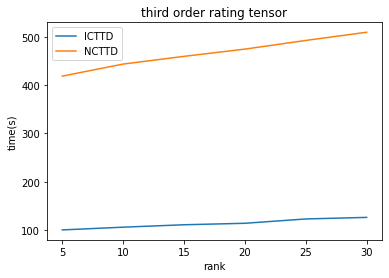

In [105]:
import matplotlib.pyplot as plt
plt.plot([5,10,15,20,25,30], [100, 105.7, 110.7, 113.76, 122.74, 126], label='ICTTD')
plt.plot([5,10,15,20,25,30],[419, 444, 460, 475, 493, 510], label='NCTTD')


#plt.ylim(0.54,0.6)
plt.legend()
plt.xlabel("rank")
plt.ylabel('time(s)')
plt.title('third order rating tensor')
#plt.ylim(2.73,2.77)
plt.show()

In [171]:
import time

start = time.time()

cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 100, verbose=False)
cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 100, verbose=False)
#cttals2(t11u,t22u,w1,w2,w3, w1c,w2c,w3c, 100, verbose=False)

end = time.time()
print(end - start)

74.0701847076416


In [ ]:
[65.7, 70.5, 67.9, 70.18, 74, 78]

In [92]:
g1_, g2_, g3_, g22_, g33_= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 100, verbose=False)

In [93]:

# calling the coupled tensor train decompsition for original tensor
#g1, g2, g3, g22, g33= cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 10, verbose=False)
# preprocessing the first core tensor, appending zeros
g1t= g1.reshape(1,2000,10)
g1t=torch.tensor(g1t)
target = torch.zeros(1, 3949, 10)
target[:, :2000, :] = g1t

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(10, 3000, 4)
target1[:, :2000, :] = g2t

# calling the coupled tensor train decompsition for incremental tensor
#g1x, g2x, g3x, g22x, g33x= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 10, verbose=False)
g1t_= g1_.reshape(1,1949,10)
g1t_=torch.tensor(g1t_)
target_ = torch.zeros(1, 3949, 10)
target_[:, :1949, :] = g1t_

# preprocessing the second core tensor, appending zeros
g2t_=torch.tensor(g2_)
target1_ = torch.zeros(10, 3000, 4)
target1_[:, :1000, :] = g2t_


#addition of first core tensors
g1n=torch.concat((target, target_), 2)

#addition of second core tensors
a=torch.zeros((10,3000,4))
b=torch.zeros((10,3000,4))
c=torch.concat((target1, a), 2)
d=torch.concat((b, target1_), 2)

g2n=torch.concat((c, d), 0)

#coverting torch tensor to numpy
#g11n=g1n.numpy()
#g22n=g2n.numpy()

#zero padding for third core tensor
g3tx=torch.tensor(g3)
target4 = torch.zeros(8, 4, 1)
target4[:4, :, :] = g3tx
target4[4:8, :, :] = g3tx
g3n=torch.concat((g3tx, g3tx), 0)


xyz=np.round(np.squeeze(np.tensordot(np.tensordot(g1n, g2n, axes=1), g3n, axes=1)),1)


In [94]:
g11n=g1n.numpy()
g22n=g2n.numpy()
g33n=g3n.numpy()
## trunctaed-SVD for compression
g11=tl.unfold(g11n,2)
g11=g11.T
u1,s1,v1=tl.partial_svd(g11,10)
s1u = np.zeros((10,10))
# populate Sigma with n x n diagonal matrix
s1u[:10, :10] = np.diag(s1)
g22=tl.tenalg.mode_dot(g22n, np.dot(s1u, v1), 0)


g22=tl.unfold(g22,2)
g22=g22.T
u2,s2,v2=tl.partial_svd(g22,4)
s2u = np.zeros((4,4))
# populate Sigma with n x n diagonal matrix
s2u[:4, :4] =np.diag(s2)


g33=tl.tenalg.mode_dot(g33n, np.dot(s2u, v2),0)

## reshaping of the new core tensors
u1u=tl.fold(u1.T,2,[1,3949,10])
u2u=tl.fold(u2.T,2,[10,3000,4])
u3u=g33

In [95]:
u1u.shape, u2u.shape, u3u.shape

((1, 3949, 10), (10, 3000, 4), (4, 4, 1))

In [96]:
g1=u1u
g2=u2u
g3=u3u

In [97]:
g2.shape

(10, 3000, 4)

In [98]:
g1_, g2_, g3_, g22_, g33_=cttals2(t11u,t22u,w1,w2,w3, w1c,w2c,w3c, 100, verbose=False)

In [99]:
g1_.shape

(1974, 10)

In [100]:
g1=g1.copy()

In [101]:
g2=g2.copy()

In [102]:
# calling the coupled tensor train decompsition for original tensor
#g1, g2, g3, g22, g33= cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 10, verbose=False)
# preprocessing the first core tensor, appending zeros
#g1t= g1.reshape(1,3949,5)
g1t=torch.tensor(g1)
target = torch.zeros(1, 6040, 10)
target[:, :3949, :] = g1t

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(10, 3952, 4)
target1[:, :3000, :] = g2t

# calling the coupled tensor train decompsition for incremental tensor
#g1x, g2x, g3x, g22x, g33x= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 10, verbose=False)
g1t_= g1_.reshape(1,1974,10)
g1t_=torch.tensor(g1t_)
target_ = torch.zeros(1, 6040, 10)
target_[:, :1974, :] = g1t_

# preprocessing the second core tensor, appending zeros
g2t_=torch.tensor(g2_)
target1_ = torch.zeros(10, 3952, 4)
target1_[:, :952, :] = g2t_


#addition of first core tensors
g1n=torch.concat((target, target_), 2)

#addition of second core tensors
a=torch.zeros((10,3952,4))
b=torch.zeros((10,3952,4))
c=torch.concat((target1, a), 2)
d=torch.concat((b, target1_), 2)

g2n=torch.concat((c, d), 0)

#coverting torch tensor to numpy
#g11n=g1n.numpy()
#g22n=g2n.numpy()

#zero padding for third core tensor
g3tx=torch.tensor(g3)
target4 = torch.zeros(8, 4, 1)
target4[:4, :, :] = g3tx
target4[4:8, :, :] = g3tx
g3n=torch.concat((g3tx, g3tx), 0)


xyz=np.round(np.squeeze(np.tensordot(np.tensordot(g1n, g2n, axes=1), g3n, axes=1)),1)


In [103]:
x=np.squeeze(xyz)
t3=torch.tensor(x)
t11=torch.tensor(ratings1)
count=0
err=0.0
for num in (torch.nonzero(t11)):
    i,j,k=num
    err+=abs(t3[i,j,k]-t11[i,j,k])
    count+=1
err/count

tensor(0.7925, dtype=torch.float64)

(6040, 3952, 4)

In [108]:
import time

start = time.time()



cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 100, verbose=False)
cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 100, verbose=False)

cttals2(t11u,t22u,w1,w2,w3, w1c,w2c,w3c, 100, verbose=False)


end = time.time()
print(end - start)

125.19193172454834


In [42]:
t1.shape, t2.shape, t11.shape, t22.shape, t11u.shape, t22u.shape

(TensorShape([2000, 2000, 4]),
 TensorShape([2000, 5, 2]),
 TensorShape([1949, 1000, 4]),
 TensorShape([1949, 5, 2]),
 TensorShape([1974, 952, 4]),
 TensorShape([1974, 5, 2]))

In [53]:

# calling the coupled tensor train decompsition for original tensor
g1, g2, g3, g22, g33= cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 2, verbose=False)

# preprocessing the first core tensor, appending zeros
g1t= g1.reshape(1,2000,5)
g1t=torch.tensor(g1t)
target = torch.zeros(1, 6040, 5)
target[:, :2000, :] = g1t

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(5, 3952, 4)
target1[:, :2000, :] = g2t

g1_, g2_, g3_, g22_, g33_= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 2, verbose=False)

# preprocessing the first core tensor, appending zeros
g1t_= g1_.reshape(1,1949,5)
g1t_=torch.tensor(g1t_)
target_ = torch.zeros(1, 6040, 5)
target_[:, :1949, :] = g1t_

# preprocessing the second core tensor, appending zeros
g2t_=torch.tensor(g2_)
target1_ = torch.zeros(5, 3952, 4)
target1_[:, :1000, :] = g2t_

# calling the coupled tensor train decompsition for incremental tensor
g1x, g2x, g3x, g22x, g33x= cttals2(t11u,t22u,w1,w2,w3, w1c,w2c,w3c, 2, verbose=False)

# preprocessing the first core tensor
g1tx= g1x.reshape(1,1974,5)
g1tx=torch.tensor(g1tx)
target2 = torch.zeros(1, 6040, 5)
target2[:, :1974, :] = g1tx

# preprocessing the second core tensor
g2tx=torch.tensor(g2x)
target3 = torch.zeros(5, 3952, 4)
target3[:, :952, :] = g2tx

#addition of first core tensors
g1n=torch.concat((torch.concat((target, target_), 2), target2),2)

#addition of second core tensors
a=torch.zeros((5,3952,4))
b=torch.zeros((5,3952,4))
c=torch.concat((target1, a), 2)
d=torch.concat((b, target1_), 2)

g2n=torch.concat((c, d), 0)
'''
a1=torch.zeros((10,3952,8))
b1=torch.zeros((10,3952,8))
c1=torch.concat((g2n, a1), 2)
d1=torch.concat((b1, target1_), 2)

g2n_=torch.concat((c1, d1), 0)

#coverting torch tensor to numpy
#g11n=g1n.numpy()
#g22n=g2n.numpy()

#zero padding for third core tensor
g3tx=torch.tensor(g3)
target4 = torch.zeros(8, 4, 1)
target4[:4, :, :] = g3tx
target4[4:8, :, :] = g3tx
g3n=torch.concat((g3tx, g3tx), 0)

#g33n=g3n.numpy()
# compression 
"""
g11n=g1n.numpy()
g22n=g2n.numpy()
g33n=g3n.numpy()
## trunctaed-SVD for compression
g11=tl.unfold(g11n,2)
g11=g11.T
u1,s1,v1=tl.partial_svd(g11,20)
s1u = np.zeros((20,20))
# populate Sigma with n x n diagonal matrix
s1u[:20, :20] = np.diag(s1)
g22=tl.tenalg.mode_dot(g22n, np.dot(s1u, v1), 0)


g22=tl.unfold(g22,2)
g22=g22.T
u2,s2,v2=tl.partial_svd(g22,4)
s2u = np.zeros((4,4))
# populate Sigma with n x n diagonal matrix
s2u[:4, :4] =np.diag(s2)


g33=tl.tenalg.mode_dot(g33n, np.dot(s2u, v2),0)

## reshaping of the new core tensors
u1u=tl.fold(u1.T,2,[1,943,20])
u2u=tl.fold(u2.T,2,[20,1682,4])
u3u=g33

xyz=np.round(np.squeeze(np.tensordot(np.tensordot(u1u, u2u, axes=1), u3u, axes=1)),1)
'''
'''

'\n#addition of second core tensors\na=torch.zeros((5,3952,4))\nb=torch.zeros((5,3952,4))\nc=torch.concat((target1, a), 2)\nd=torch.concat((b, target3), 2)\n\ng2n=torch.concat((c, d), 0)\n\n#coverting torch tensor to numpy\n#g11n=g1n.numpy()\n#g22n=g2n.numpy()\n\n#zero padding for third core tensor\ng3tx=torch.tensor(g3)\ntarget4 = torch.zeros(8, 4, 1)\ntarget4[:4, :, :] = g3tx\ntarget4[4:8, :, :] = g3tx\ng3n=torch.concat((g3tx, g3tx), 0)\n\n#g33n=g3n.numpy()\n# compression \n"""\ng11n=g1n.numpy()\ng22n=g2n.numpy()\ng33n=g3n.numpy()\n## trunctaed-SVD for compression\ng11=tl.unfold(g11n,2)\ng11=g11.T\nu1,s1,v1=tl.partial_svd(g11,20)\ns1u = np.zeros((20,20))\n# populate Sigma with n x n diagonal matrix\ns1u[:20, :20] = np.diag(s1)\ng22=tl.tenalg.mode_dot(g22n, np.dot(s1u, v1), 0)\n\n\ng22=tl.unfold(g22,2)\ng22=g22.T\nu2,s2,v2=tl.partial_svd(g22,4)\ns2u = np.zeros((4,4))\n# populate Sigma with n x n diagonal matrix\ns2u[:4, :4] =np.diag(s2)\n\n\ng33=tl.tenalg.mode_dot(g33n, np.dot(s2u, v2

In [71]:
#addition of first core tensors
g1n=torch.concat((torch.concat((target, target_), 2), target2),2)

#addition of second core tensors
a=torch.zeros((5,3952,4))
b=torch.zeros((5,3952,4))
c=torch.concat((target1, a), 2)
d=torch.concat((b, target1_), 2)

g2n=torch.concat((c, d), 0)

In [72]:
g2n.shape

torch.Size([10, 3952, 8])

In [73]:
g22n=g2n.numpy()
g2n=tl.unfold(g22n,2)
g2n=g2n.T
u1,s1,v1=tl.partial_svd(g2n,4)

In [74]:
g2n=tl.fold(u1, 0, [10, 3952,4])

In [76]:
#g22n=g2n.numpy()
g2n=tl.unfold(g2n,0)
g2n=g2n.T
u1,s1,v1=tl.partial_svd(g2n,5)

In [87]:
g2n=tl.fold(u1, 0, [5, 3952,4])

In [89]:
g2n=torch.tensor(g2n)

In [90]:
g2n.shape, a1.shape

(torch.Size([5, 3952, 4]), torch.Size([5, 3952, 4]))

In [91]:
a1=torch.zeros((5,3952,4))
b1=torch.zeros((5,3952,4))
c1=torch.concat((g2n, a1), 2)
d1=torch.concat((b1, target1_), 2)

g2n_=torch.concat((c1, d1), 0)

In [92]:
g3tx=torch.tensor(g3)
target4 = torch.zeros(8, 4, 1)
target4[:4, :, :] = g3tx
target4[4:8, :, :] = g3tx
g3n=torch.concat((g3tx, g3tx), 0)

torch.Size([10, 3952, 8])

In [100]:
g1n=g1n.numpy()
g1n=tl.unfold(g1n,2)
g1n=g1n.T
u11,s11,v11=tl.partial_svd(g1n,10)

In [94]:
np.round(np.squeeze(np.tensordot(np.tensordot(g1n, g2n_, axes=1), g3n, axes=1)),1)

ValueError: shape-mismatch for sum

In [102]:
import time

#start = time.time()


tracemalloc.start()
# calling the coupled tensor train decompsition for original tensor
g1, g2, g3, g22, g33= cttals(t1,t2,y1,y2,y3, y1c,y2c,y3c, 10, verbose=False)

# preprocessing the first core tensor, appending zeros
g1t= g1.reshape(1,2000,5)
g1t=torch.tensor(g1t)
target = torch.zeros(1, 6040, 5)
target[:, :2000, :] = g1t

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(5, 3952, 4)
target1[:, :2000, :] = g2t

# calling the coupled tensor train decompsition for incremental tensor
g1x1, g2x1, g3x1, g22x1, g33x1= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 10, verbose=False)

# preprocessing the first core tensor, appending zeros
g1t1= g1x1.reshape(1,1949,5)
g1t1=torch.tensor(g1t1)
target = torch.zeros(1, 6040, 5)
target4[:, :1949, :] = g1t1

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(5, 3952, 4)
target1[:, :1000, :] = g2t

# calling the coupled tensor train decompsition for second incremental tensor
g1x, g2x, g3x, g22x, g33x= cttals1(t11,t22,z1,z2,z3, z1c,z2c,z3c, 10, verbose=False)

# preprocessing the first core tensor, appending zeros
g1t= g1.reshape(1,2000,5)
g1t=torch.tensor(g1t)
target = torch.zeros(1, 6040, 5)
target[:, :1949, :] = g1t

# preprocessing the second core tensor, appending zeros
g2t=torch.tensor(g2)
target1 = torch.zeros(5, 3952, 4)
target1[:, :1000, :] = g2t


# preprocessing the first core tensor
g1tx= g1x.reshape(1,675,5)
g1tx=torch.tensor(g1tx)
target2 = torch.zeros(1, 6040, 5)
target2[:, :675, :] = g1tx

# preprocessing the second core tensor
g2tx=torch.tensor(g2x)
target3 = torch.zeros(5, 3952, 4)
target3[:, :351, :] = g2tx

#addition of first core tensors
g1n=torch.concat((target, target2), 2)

#addition of second core tensors
a=torch.zeros((5,3952,4))
b=torch.zeros((5,3952,4))
c=torch.concat((target1, a), 2)
d=torch.concat((b, target3), 2)

g2n=torch.concat((c, d), 0)

#coverting torch tensor to numpy
#g11n=g1n.numpy()
#g22n=g2n.numpy()

#zero padding for third core tensor
g3tx=torch.tensor(g3)
target4 = torch.zeros(8, 4, 1)
target4[:4, :, :] = g3tx
target4[4:8, :, :] = g3tx
g3n=torch.concat((g3tx, g3tx), 0)

#g33n=g3n.numpy()
# compression 
"""
g11n=g1n.numpy()
g22n=g2n.numpy()
g33n=g3n.numpy()
## trunctaed-SVD for compression
g11=tl.unfold(g11n,2)
g11=g11.T
u1,s1,v1=tl.partial_svd(g11,20)
s1u = np.zeros((20,20))
# populate Sigma with n x n diagonal matrix
s1u[:20, :20] = np.diag(s1)
g22=tl.tenalg.mode_dot(g22n, np.dot(s1u, v1), 0)


g22=tl.unfold(g22,2)
g22=g22.T
u2,s2,v2=tl.partial_svd(g22,4)
s2u = np.zeros((4,4))
# populate Sigma with n x n diagonal matrix
s2u[:4, :4] =np.diag(s2)


g33=tl.tenalg.mode_dot(g33n, np.dot(s2u, v2),0)

## reshaping of the new core tensors
u1u=tl.fold(u1.T,2,[1,943,20])
u2u=tl.fold(u2.T,2,[20,1682,4])
u3u=g33

xyz=np.round(np.squeeze(np.tensordot(np.tensordot(u1u, u2u, axes=1), u3u, axes=1)),1)

end = time.time()
print(end - start)
"""
'''

(12778837, 155490761)


'\n# preprocessing the first core tensor\ng1tx= g1x.reshape(1,675,5)\ng1tx=torch.tensor(g1tx)\ntarget2 = torch.zeros(1, 6040, 5)\ntarget2[:, :675, :] = g1tx\n\n# preprocessing the second core tensor\ng2tx=torch.tensor(g2x)\ntarget3 = torch.zeros(5, 3952, 4)\ntarget3[:, :351, :] = g2tx\n\n#addition of first core tensors\ng1n=torch.concat((target, target2), 2)\n\n#addition of second core tensors\na=torch.zeros((5,3952,4))\nb=torch.zeros((5,3952,4))\nc=torch.concat((target1, a), 2)\nd=torch.concat((b, target3), 2)\n\ng2n=torch.concat((c, d), 0)\n\n#coverting torch tensor to numpy\n#g11n=g1n.numpy()\n#g22n=g2n.numpy()\n\n#zero padding for third core tensor\ng3tx=torch.tensor(g3)\ntarget4 = torch.zeros(8, 4, 1)\ntarget4[:4, :, :] = g3tx\ntarget4[4:8, :, :] = g3tx\ng3n=torch.concat((g3tx, g3tx), 0)\n\n#g33n=g3n.numpy()\n# compression \n"""\ng11n=g1n.numpy()\ng22n=g2n.numpy()\ng33n=g3n.numpy()\n## trunctaed-SVD for compression\ng11=tl.unfold(g11n,2)\ng11=g11.T\nu1,s1,v1=tl.partial_svd(g11,20)

In [512]:
without=[219+170, 233, 242, 247, 260, 267]
with1=[192, 197, 203, 210, 217, 239]
without=[389, 406, 421, 429, 438, 447]

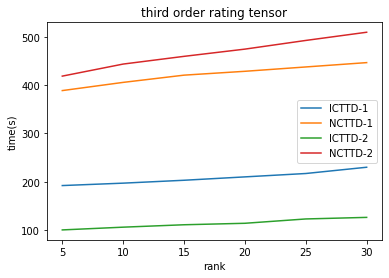

In [172]:
import matplotlib.pyplot as plt
plt.plot([5,10,15,20,25,30], [192, 197, 203, 210, 217, 230], label='ICTTD-1')
plt.plot([5,10,15,20,25,30],[389, 406, 421, 429, 438, 447], label='NCTTD-1')
plt.plot([5,10,15,20,25,30], [100, 105.7, 110.7, 113.76, 122.74, 126], label='ICTTD-2')
plt.plot([5,10,15,20,25,30],[419, 444, 460, 475, 493, 510], label='NCTTD-2')


#plt.ylim(0.54,0.6)
plt.legend()
plt.xlabel("rank")
plt.ylabel('time(s)')
plt.title('third order rating tensor')
#plt.ylim(2.73,2.77)
plt.show()

In [504]:
ratings_test=np.zeros((6040,3952,4))

In [505]:
# ratings_df dataframe to ratings1 ndarray
for row in ratings_df.itertuples(index = True):
    ratings_test[row.userId-1, row.movieId-1, row.session-1]  = row.rating

# compute the non-zero elements in the ratings1 tensor
matrix_size = np.prod(ratings_test.shape)
interaction = np.flatnonzero(ratings_test).shape[0]
sparsity = 100 * (interaction / matrix_size)

print('dimension: ', ratings_test.shape)
print('sparsity: {:.4f}%'.format(sparsity))
interaction

dimension:  (6040, 3952, 4)
sparsity: 0.9895%


944812

In [506]:
#ratings_test=tf.convert_to_tensor(ratings_test)

#ratings_test=ratings_test.numpy()


ratings_test=torch.from_numpy(ratings_test)


xyz=np.squeeze(np.tensordot(np.tensordot(g1n, g2n, axes=1), g3n, axes=1))



In [507]:
err=0.0
count=0
for num in (np.nonzero(ratings_test)):
    i,j,k=num
    err=err+abs((ratings_test[i,j,k])-xyz[i,j,k])
 
   
    count+=1
train_err_ctt=(err/count)

In [508]:
train_err_ctt

tensor(0.6062, dtype=torch.float64)

In [437]:
xyz=np.squeeze(np.tensordot(np.tensordot(g1n, g2n, axes=1), g3n, axes=1))

In [438]:
xyz=torch.from_numpy(xyz)

In [442]:
err=0.0
count=0
count1=0
for k, v in ratings_test1.iterrows():
    i=int(v[0])
    j=int(v[1])
    m=int(v[4])
    l=(v[2])

    count+=1
    err+=abs((xyz[i-1,j-1,m-1]-l))
test_err_ctt= (err/count)
#test_mae_ctt.append(test_err_ctt)
print(test_err_ctt)

tensor(0.6123, dtype=torch.float64)


In [ ]:
[0.6367, 0.6221, 0.6128, 0.6039, 0.5927, 0.58]
final=[0.6062, 0.5860, 0.5710, 0.5607, 0.5521, 0.5447]

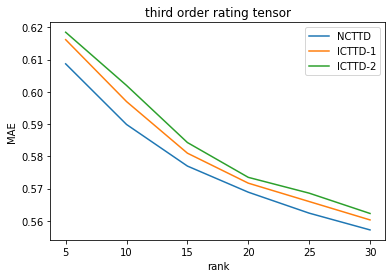

In [173]:
import matplotlib.pyplot as plt
plt.plot([5,10,15,20,25,30],[0.6087, 0.5899, 0.5770, 0.5689, 0.5624, 0.5572], label='NCTTD')
plt.plot([5,10,15,20,25,30], [0.6162, 0.5970, 0.5810, 0.5717, 0.566, 0.5603], label='ICTTD-1')
plt.plot([5,10,15,20,25,30], [0.6185, 0.6020, 0.5843, 0.5735, 0.5686, 0.5623], label='ICTTD-2')

#plt.ylim(0.54,0.6)
plt.legend()
plt.xlabel("rank")
plt.ylabel('MAE')
plt.title('third order rating tensor')
#plt.ylim(0.5,0.65)
plt.show()

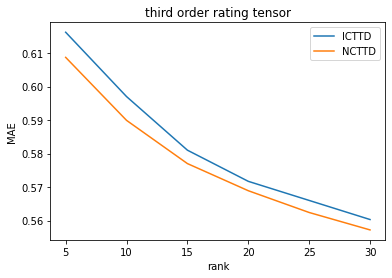

In [525]:
import matplotlib.pyplot as plt
plt.plot([5,10,15,20,25,30], [0.6162, 0.5970, 0.5810, 0.5717, 0.566, 0.5603], label='ICTTD')
plt.plot([5,10,15,20,25,30],[0.6087, 0.5899, 0.5770, 0.5689, 0.5624, 0.5572], label='NCTTD')


#plt.ylim(0.54,0.6)
plt.legend()
plt.xlabel("rank")
plt.ylabel('MAE')
plt.title('third order rating tensor')
#plt.ylim(2.73,2.77)
plt.show()

In [ ]:
[0.6367, 0.6221, 0.6128, 0.6039, 0.6037, 0.5982]
[145, 151, 157, 166]
[5, 10,15, 25]

In [3]:
1#last and final
CTT_user=[181, 216, 302, 449, 521, 577]
CCP_user=[172, 192, 288, 408, 494, 536]
CTucker_user=[174, 175, 242, 311, 376, 414]

CTT=[0.6087, 0.5899, 0.5770, 0.5689, 0.5624, 0.5572]
CCP=[0.6089, 0.5900, 0.5771, 0.5692, 0.5620, 0.5565]
CTucker=[0.6087, 0.5900, 0.5769, 0.5685, 0.5617, 0.5564]